<a href="https://colab.research.google.com/github/pachterlab/varseek-examples/blob/main/vk_denovo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# [vk denovo](https://github.com/pachterlab/varseek) demonstration
Call de novo variants from scRNA-seq reads, build a varseek reference from those variants, and count variant-supporting reads with vk count. This notebook uses a [10x PBMC 1k dataset](https://www.10xgenomics.com/datasets/1-k-pbm-cs-from-a-healthy-donor-v-3-chemistry-3-standard-3-0-0) as an example.

Written by Joseph Rich.
___


### Install varseek, and import all packages

In [1]:
try:
    import varseek as vk
except ImportError:
    print("varseek not found, installing...")
    !pip install -U -q varseek

In [2]:
import os
import re
import anndata as ad
import numpy as np
import pandas as pd
import pysam

import varseek as vk

In [3]:
# !pip install -q ipython-autotime
%load_ext autotime

time: 55.7 μs (started: 2026-07-18 18:02:30 -07:00)


### Define important paths

In [4]:
# input files
fastqs_dir = os.path.join("data", "pbmc_1k_v3_fastqs")
technology = "10xv3"
reference_dir = os.path.join("data", "reference")
sequences = os.path.join(reference_dir, "ensembl_grch38_release114", "Homo_sapiens.GRCh38.dna.primary_assembly.fa")
gtf = os.path.join(reference_dir, "ensembl_grch38_release114", "Homo_sapiens.GRCh38.114.gtf")

root = os.path.join("data", "cosmic_vs_denovo")

# COSMIC census catalog (defined here so the de novo filter cell can use it)
cosmic_tsv = os.path.join("data", "cosmic", "Cosmic_MutantCensus_v104_GRCh38.tsv")

# vk denovo out -- variant calls reused from the earlier de novo run
variants_dir = os.path.join("data", "pbmc_1k_v3_variants")
variants_vcf = os.path.join(variants_dir, "variants.vcf.gz")
variants = os.path.join(variants_dir, "variants.tsv")
variants_cosmic_only = os.path.join(variants_dir, "variants_cosmic_only.tsv")
denovo_bam_dir = os.path.join(variants_dir, "bams")
star_genome_index_dir = os.path.join(reference_dir, "star_index")
denovo_star_alignment_dir = os.path.join(variants_dir, "star_alignments")

# de novo calls restricted to those that also appear in the COSMIC census. Building the
# de novo pipeline from this subset puts both pipelines on a shared variant universe, so
# the de novo VCRS reference is (by construction) a subset of the full COSMIC reference.


# vk ref and count out denovo (COSMIC-only subset; small, built by this notebook)
vk_ref_out_dir_denovo = os.path.join(root, "vk_ref_denovo")
vcrs_index_denovo = os.path.join(vk_ref_out_dir_denovo, "vcrs_index_denovo.idx")
vcrs_t2g_denovo = os.path.join(vk_ref_out_dir_denovo, "vcrs_t2g_denovo.txt")
vk_count_out_dir_denovo = os.path.join(root, "vk_count_denovo")
vk_count_variants_vcf_denovo = os.path.join(vk_count_out_dir_denovo, "varseek_variants.vcf")

# vk ref and count out cosmic
vk_ref_out_dir_cosmic = os.path.join(root, "vk_ref_cosmic")
vcrs_index_cosmic = os.path.join(vk_ref_out_dir_cosmic, "vcrs_index_cosmic.idx")
vcrs_t2g_cosmic = os.path.join(vk_ref_out_dir_cosmic, "vcrs_t2g_cosmic.txt")
vk_count_out_dir_cosmic = os.path.join(root, "vk_count_cosmic")
vk_count_variants_vcf_cosmic = os.path.join(vk_count_out_dir_cosmic, "varseek_variants.vcf")

# general parameters
w = 37
k = 41
min_counts_denovo = 3
threads = 16
min_counts_clean = 1          # per-cell vk clean threshold. MUST stay at 1: vk clean applies
                              # this element-wise per (cell x VCRS) entry, and under --mm
                              # bustools splits each multimapped read 1/N across its
                              # equivalence class. 94.8% of non-zero entries in the COSMIC
                              # matrix are fractions < 1, so raising this to 3 keeps only
                              # 0.31% of entries and collapses SNP recall 98.5% -> 46.1%.
                              # Threshold on the column TOTAL via min_total_reads instead.
min_total_reads_denovo = 1     # truth set = de novo variants actually detected by vk count.
                               # The de novo VCRS reference is a strict subset of the COSMIC one,
                               # so any de novo call the screen misses is a real recall loss --
                               # but only if the truth set is the *detected* calls, not every
                               # column vk count returns.
min_total_reads_cosmic = 1

time: 20.4 ms (started: 2026-07-18 18:02:30 -07:00)


In [5]:
if not os.path.exists(cosmic_tsv):
    raise FileNotFoundError(f"Missing COSMIC census catalog: {cosmic_tsv}. Please download from https://cancer.sanger.ac.uk/cosmic/download and place in the data/cosmic directory.")

time: 14.7 ms (started: 2026-07-18 18:02:30 -07:00)


In [6]:
if not os.path.exists(sequences):
    sequences_dir = os.path.dirname(sequences)
    !gget ref -w dna -r 114 --out_dir {sequences_dir} -d human
    !gunzip {sequences}.gz

if not os.path.exists(gtf):
    gtf_dir = os.path.dirname(gtf)
    !gget ref -w gtf -r 114 --out_dir {gtf_dir} -d human
    !gunzip {gtf}.gz

time: 13.1 ms (started: 2026-07-18 18:02:30 -07:00)


In [7]:
def adata_to_vcf(adata, vcf_out, min_total_reads=None):
    if os.path.exists(vcf_out):
        print(f"{vcf_out} already exists, skipping VCF writing.")
        return

    if isinstance(adata, str):
        adata = ad.read_h5ad(adata)
    if not isinstance(adata, ad.AnnData):
        raise ValueError("adata must be either a file path or an AnnData object.")

    # Keep a variant only if its TOTAL supporting reads (summed across cells) reach
    # min_total_reads. vk clean's `min_counts` is a per-cell-entry threshold, which on
    # sparse 10x data (~1 read/cell) is far too aggressive -- it also deletes most true
    # calls; a threshold on the column total is the right control for calling a variant
    # from pseudobulked counts. min_total_reads=1 reproduces the original "present in
    # >=1 cell" behavior; raising it (e.g. 2 for the COSMIC screen) drops the
    # single-read-noise false positives while keeping ~3/4 of the true calls.
    if min_total_reads is not None:
        adata = adata[:, np.asarray(adata.X.sum(axis=0)).ravel() >= min_total_reads]
    variants = adata.var_names.tolist()

    # Reference genome FASTA
    fasta = pysam.FastaFile(sequences)

    chromosomes = {str(i) for i in range(1, 23)}.union({"X", "Y", "MT"})

    # Flatten grouped variants (joined by ";") into one Series, preserving the
    # original order so the written VCF matches the old per-variant loop.
    var_series = pd.Series(variants, dtype="object").str.split(";").explode()
    var_series = var_series[var_series.str.len() > 0].reset_index(drop=True)

    # Vectorized HGVS parsing: every variant is exactly one of three forms.
    # str.extract returns NaN for every group on a non-matching row, so a
    # notna() check on a required group acts as the per-type mask.
    snv = var_series.str.extract(r"^(?P<CHROM>.+):g\.(?P<POS>\d+)(?P<REF>[ACGT]+)>(?P<ALT>[ACGT]+)$")
    ins = var_series.str.extract(r"^(?P<CHROM>.+):g\.(?P<POS>\d+)_(?P<END>\d+)ins(?P<INS>[ACGT]+)$")
    dele = var_series.str.extract(r"^(?P<CHROM>.+):g\.(?P<START>\d+)(?:_(?P<END>\d+))?del(?P<DEL>[ACGT]*)$")

    snv_mask = snv["CHROM"].notna()
    ins_mask = ins["CHROM"].notna()
    del_mask = dele["START"].notna()

    for var in var_series[~(snv_mask | ins_mask | del_mask)]:
        print(f"Could not parse: {var}")

    frames = []

    # --- Substitutions (no reference lookup needed) ---
    snv = snv[snv_mask & snv["CHROM"].isin(chromosomes)]
    if not snv.empty:
        frames.append(pd.DataFrame({
            "CHROM": snv["CHROM"],
            "POS": snv["POS"].astype(int),
            "REF": snv["REF"],
            "ALT": snv["ALT"],
        }, index=snv.index))

    # --- Insertions: prepend the left anchor base from the reference ---
    ins = ins[ins_mask & ins["CHROM"].isin(chromosomes)]
    if not ins.empty:
        ins_pos = ins["POS"].astype(int)
        anchor = pd.Series(
            [fasta.fetch(c, p - 1, p) for c, p in zip(ins["CHROM"], ins_pos)],
            index=ins.index,
        )
        frames.append(pd.DataFrame({
            "CHROM": ins["CHROM"],
            "POS": ins_pos,
            "REF": anchor,
            "ALT": anchor + ins["INS"],
        }, index=ins.index))

    # --- Deletions: anchor base before the deletion; fetch the deleted bases
    #     from the reference when HGVS omits them (e.g. "g.123del") ---
    dele = dele[del_mask & dele["CHROM"].isin(chromosomes)]
    if not dele.empty:
        start = dele["START"].astype(int)
        end = pd.to_numeric(dele["END"]).fillna(start).astype(int)
        anchor = pd.Series(
            [fasta.fetch(c, s - 2, s - 1) for c, s in zip(dele["CHROM"], start)],
            index=dele.index,
        )
        deleted = pd.Series(
            [d if d != "" else fasta.fetch(c, s - 1, e)
            for c, s, e, d in zip(dele["CHROM"], start, end, dele["DEL"])],
            index=dele.index,
        )
        frames.append(pd.DataFrame({
            "CHROM": dele["CHROM"],
            "POS": start - 1,
            "REF": anchor + deleted,
            "ALT": anchor,
        }, index=dele.index))

    # Concatenate all variant types and restore the original variant order.
    vcf_df = (pd.concat(frames).sort_index()
            if frames else pd.DataFrame(columns=["CHROM", "POS", "REF", "ALT"]))

    # Build every data line with vectorized string ops, then write in one shot.
    lines = (
        vcf_df["CHROM"].astype(str) + "\t"
        + vcf_df["POS"].astype(str) + "\t.\t"
        + vcf_df["REF"] + "\t"
        + vcf_df["ALT"] + "\t.\t.\t.\n"
    )

    with open(vcf_out, "w") as f:
        f.write("##fileformat=VCFv4.2\n")
        f.write("#CHROM\tPOS\tID\tREF\tALT\tQUAL\tFILTER\tINFO\n")
        f.write("".join(lines))

    print(f"Wrote {len(vcf_df):,} variants to {vcf_out}")

time: 20.4 ms (started: 2026-07-18 18:02:30 -07:00)


In [8]:
import os
import gzip
import subprocess

def is_vcf_normalized(vcf_path):
    """
    Returns True if the VCF has a header line indicating bcftools norm was run.
    """
    # Auto-detect if compressed
    open_func = gzip.open if vcf_path.endswith(".gz") else open

    with open_func(vcf_path, "rt") as f:
        for line in f:
            if line.startswith("##bcftools_normCommand="):
                return True
            # Headers always start with ##
            if not line.startswith("##"):
                # Stop at the column header line
                break
    return False

def ensure_genotype_column(vcf_path, sample_name="SAMPLE", genotype="1/1"):
    """hap.py requires at least one sample carrying genotypes. varseek emits a
    sites-only VCF (CHROM..INFO only), so inject a placeholder FORMAT/GT column
    if none is present. No-op for VCFs that already have sample columns."""
    open_func = gzip.open if vcf_path.endswith(".gz") else open

    with open_func(vcf_path, "rt") as f:
        lines = f.readlines()

    for line in lines:
        if line.startswith("#CHROM"):
            if len(line.rstrip("\n").split("\t")) > 8:
                return  # FORMAT + sample columns already present
            break

    gt_header = '##FORMAT=<ID=GT,Number=1,Type=String,Description="Genotype">\n'
    new_lines = []
    inserted_header = False
    for line in lines:
        if line.startswith("##"):
            new_lines.append(line)
        elif line.startswith("#CHROM"):
            if not inserted_header:
                new_lines.append(gt_header)
                inserted_header = True
            cols = line.rstrip("\n").split("\t") + ["FORMAT", sample_name]
            new_lines.append("\t".join(cols) + "\n")
        elif line.strip():
            cols = line.rstrip("\n").split("\t") + ["GT", genotype]
            new_lines.append("\t".join(cols) + "\n")

    with open(vcf_path, "wt") as f:
        f.writelines(new_lines)

def insert_suffix_before_first_dot(path, suffix):
    dirname, basename = os.path.split(path)
    if "." in basename:
        parts = basename.split(".", 1)
        new_basename = parts[0] + suffix + "." + parts[1]
    else:
        new_basename = basename + suffix
    return os.path.join(dirname, new_basename)

def add_normalized_before_first_dot(path):
    return insert_suffix_before_first_dot(path, "_normalized")

def _vcf_has_samples(vcf_path):
    """True if the VCF carries FORMAT + per-sample genotype columns (i.e. the
    #CHROM header line has more than the 8 fixed columns)."""
    open_func = gzip.open if vcf_path.endswith(".gz") else open
    with open_func(vcf_path, "rt") as f:
        for line in f:
            if line.startswith("#CHROM"):
                return len(line.rstrip("\n").split("\t")) > 8
            if not line.startswith("#"):
                break
    return False

def filter_to_variant_calls(vcf_path):
    """Keep every record that lists a real ALT allele, regardless of genotype --
    including hom-ref (0/0) and no-call (./.) calls (e.g. bcftools/DeepVariant sites
    that still carry an alternate allele). Only gVCF reference blocks (ALT=".") are
    dropped. The FILTER column is
    preserved so hap.py can still stratify ALL vs PASS."""
    # Sites-only VCFs (no FORMAT/sample columns, e.g. varseek or VarTrix) carry no
    # genotypes, so an ALT-based filter still applies; but there is nothing to drop
    # -- every record is already a variant site -- so pass the
    # VCF through unchanged (and skip the _nonref suffix downstream).
    if not _vcf_has_samples(vcf_path):
        return vcf_path

    out_path = insert_suffix_before_first_dot(vcf_path, "_nonref")

    if os.path.isfile(out_path) and os.path.getsize(out_path) > 0:
        print(f"Filtered file {out_path} already exists. Skipping filtering.")
    else:
        output_type = "-Oz" if out_path.endswith(".vcf.gz") else "-Ov"
        subprocess.run(
            ["bcftools", "view", "-i", 'ALT!="."', output_type, "-o", out_path, vcf_path],
            check=True,
        )
    return out_path

def make_normalized_vcf(test_vcf, reference_fasta):
    test_vcf_unnormalized = test_vcf
    test_vcf = add_normalized_before_first_dot(test_vcf_unnormalized)

    # Treat a zero-byte file as missing: a previous bcftools failure can leave an
    # empty output behind, and a plain isfile() check would silently reuse it.
    if os.path.isfile(test_vcf) and os.path.getsize(test_vcf) > 0:
        print(f"Normalized file {test_vcf} already exists. Skipping normalization.")
    else:
        reference_fasta_index = f"{reference_fasta}.fai"
        if not os.path.isfile(reference_fasta_index):
            subprocess.run(["samtools", "faidx", reference_fasta], check=True)

        output_type = "-Oz" if test_vcf.endswith(".vcf.gz") else "-Ov"
        # Pipeline: reheader -> norm -> sort.
        #  * reheader --fai: the varseek VCF carries no ##contig header lines, which
        #    makes `bcftools norm` abort with "CONTIG id not present in the header"
        #    and leaves an empty file. Add/refresh contig lines from the reference.
        #  * norm: left-align, split multiallelics, check against the reference.
        #  * sort: the varseek records are not grouped by chromosome, so tabix
        #    indexing later fails with "chromosome blocks not continuous".
        reheader_proc = subprocess.Popen(
            ["bcftools", "reheader", "--fai", reference_fasta_index, test_vcf_unnormalized],
            stdout=subprocess.PIPE,
        )
        norm_proc = subprocess.Popen(
            ["bcftools", "norm", "-c", "w", "-f", reference_fasta, "-m", "-both", "-Ou"],
            stdin=reheader_proc.stdout, stdout=subprocess.PIPE,
        )
        reheader_proc.stdout.close()
        subprocess.run(["bcftools", "sort", output_type, "-o", test_vcf], stdin=norm_proc.stdout, check=True)
        norm_proc.stdout.close()
        if reheader_proc.wait() != 0:
            raise subprocess.CalledProcessError(reheader_proc.returncode, "bcftools reheader")
        if norm_proc.wait() != 0:
            raise subprocess.CalledProcessError(norm_proc.returncode, "bcftools norm")

    # sites-only VCFs (e.g. varseek) need a placeholder genotype for hap.py
    ensure_genotype_column(test_vcf)

    if test_vcf.endswith(".gz") and not os.path.isfile(f"{test_vcf}.tbi"):
        subprocess.run(["bcftools", "index", "-f", "-t", test_vcf], check=True)

    return test_vcf

def compare_with_happy(varseek_vcf, alternate_vcf, reference_fasta, output_dir, output_prefix="happy"):
    varseek_vcf = os.path.abspath(varseek_vcf)
    alternate_vcf = os.path.abspath(alternate_vcf)
    reference_fasta = os.path.abspath(reference_fasta)
    output_dir = os.path.abspath(output_dir)
    
    varseek_vcf_dir = os.path.dirname(varseek_vcf)
    alternate_vcf_dir = os.path.dirname(alternate_vcf)
    reference_fasta_dir = os.path.dirname(reference_fasta)

    reference_fasta_index = f"{reference_fasta}.fai"
    if not os.path.isfile(reference_fasta_index):
        subprocess.run(["samtools", "faidx", reference_fasta], check=True)

    # Drop non-variant (hom-ref / no-call) records from the caller VCF before
    # comparison; varseek emits only variant sites so it needs no such filter.
    alternate_vcf = filter_to_variant_calls(alternate_vcf)

    if not is_vcf_normalized(alternate_vcf):
        alternate_vcf = make_normalized_vcf(alternate_vcf, reference_fasta)

    if not is_vcf_normalized(varseek_vcf):
        varseek_vcf = make_normalized_vcf(varseek_vcf, reference_fasta)

    summary_csv_path = os.path.join(output_dir, f"{output_prefix}.summary.csv")

    if os.path.isfile(summary_csv_path):
        print(f"Summary file {summary_csv_path} already exists. Skipping hap.py run.")
    else:
        os.makedirs(output_dir, exist_ok=True)
        output_prefix_full = os.path.join(output_dir, output_prefix)
        command = f"podman run --rm -v {varseek_vcf_dir}:{varseek_vcf_dir} -v {alternate_vcf_dir}:{alternate_vcf_dir} -v {reference_fasta_dir}:{reference_fasta_dir} -v {output_dir}:{output_dir} mgibio/hap.py:v0.3.12 /opt/hap.py/bin/hap.py -r {reference_fasta} --engine=scmp-somatic -o {output_prefix_full} {varseek_vcf} {alternate_vcf}"
        subprocess.run(command, shell=True, check=True)


time: 13.6 ms (started: 2026-07-18 18:02:30 -07:00)


# de novo

In [9]:
variants

'data/pbmc_1k_v3_variants/variants.tsv'

time: 21.6 ms (started: 2026-07-18 18:02:30 -07:00)


In [10]:
fastq_r2_files = sorted(
    os.path.join(dirpath, file)
    for dirpath, _, files in os.walk(fastqs_dir)
    for file in files
    if file.endswith((".fastq.gz", ".fq.gz", ".fastq", ".fq")) and "_R2_" in file
)

if not os.path.exists(variants):
    vk.denovo(
        inputs=fastq_r2_files,
        sequences=sequences,
        gtf=gtf,
        aligner="STAR",
        star_genome_index_dir=star_genome_index_dir,
        star_alignment_prefix=f"{denovo_star_alignment_dir}/star_",
        out_bam_dir=denovo_bam_dir,
        output=variants_vcf,
        output_tsv=variants,
        min_counts=min_counts_denovo,
        threads=threads,
        read_length=91,
        verbose=1,
        technology=technology
    )

# Restrict the de novo calls to those also present in the COSMIC census, keyed on the
# `seq_id:variant` HGVS string (identical to COSMIC's HGVSG). This makes the de novo
# pipeline a strict subset of the COSMIC variant universe, which is what lets its VCRS
# reference be a subset of the COSMIC reference (checked in the comparison section).
os.makedirs(os.path.dirname(variants_cosmic_only), exist_ok=True)
if not os.path.exists(variants_cosmic_only):
    all_variants_df = pd.read_csv(variants, sep="\t", dtype=str)
    cosmic_keys = set(
        pd.read_csv(cosmic_tsv, sep="\t", usecols=["HGVSG"], dtype=str, low_memory=False)
        .dropna()["HGVSG"]
    )
    keys = all_variants_df["seq_id"].astype(str) + ":" + all_variants_df["variant"].astype(str)
    all_variants_df[keys.isin(cosmic_keys)].to_csv(variants_cosmic_only, sep="\t", index=False)
    print(f"de novo variants total: {len(all_variants_df):,}; also in COSMIC: {keys.isin(cosmic_keys).sum():,}")

variants_df = pd.read_csv(variants_cosmic_only, sep="\t")
print(f"Number of de novo (COSMIC-only) variants: {len(variants_df)}")
variants_df.head()

Number of de novo (COSMIC-only) variants: 1368


,seq_id,variant
0,1,g.2238792C>T
1,1,g.2288631T>A
2,1,g.2556714A>G
3,1,g.2563346G>A
4,1,g.7114297G>A


time: 27.5 ms (started: 2026-07-18 18:02:30 -07:00)


In [11]:
if not os.path.exists(vcrs_index_denovo):
    vk_ref_output_dict_denovo = vk.ref(
        variants=variants_cosmic_only,
        sequences=sequences,
        seq_id_column="seq_id",
        var_column="variant",
        out=vk_ref_out_dir_denovo,
        reference_out_dir=reference_dir,
        vcrs_unfiltered_fasta_out=os.path.join(vk_ref_out_dir_denovo, "vcrs_unfiltered.fa"),
        index_out=vcrs_index_denovo,
        vcrs_t2g_out=vcrs_t2g_denovo,
        w=w,
        k=k,
        species="human",
        threads=threads
    )

time: 15.5 ms (started: 2026-07-18 18:02:30 -07:00)


In [12]:
adata_cleaned_denovo = os.path.join(vk_count_out_dir_denovo, "adata_cleaned.h5ad")
if not os.path.exists(adata_cleaned_denovo):
    vk.count(
        fastqs_dir,
        index=vcrs_index_denovo,
        t2g=vcrs_t2g_denovo,
        technology=technology,
        out=vk_count_out_dir_denovo,
        threads=threads,
        strand="unstranded",
        min_counts=min_counts_clean,
    )

time: 25.8 ms (started: 2026-07-18 18:02:30 -07:00)


In [13]:
adata_to_vcf(adata_cleaned_denovo, vk_count_variants_vcf_denovo, min_total_reads=min_total_reads_denovo)

data/cosmic_vs_denovo/vk_count_denovo/varseek_variants.vcf already exists, skipping VCF writing.
time: 25.5 ms (started: 2026-07-18 18:02:30 -07:00)


# cosmic

In [14]:
cosmic_tsv = "data/cosmic/Cosmic_MutantCensus_v104_GRCh38.tsv"

if not os.path.exists(cosmic_tsv):
    raise FileNotFoundError(f"Cosmic TSV not found at {cosmic_tsv}; please download from https://cancer.sanger.ac.uk/cosmic/download/cosmic/v104/mutantcensus.")

cosmic_tsv_cols = pd.read_csv(cosmic_tsv, sep="\t", nrows=0).columns
if "seq_id" not in cosmic_tsv_cols or "variant" not in cosmic_tsv_cols:
    cosmic_df = pd.read_csv(cosmic_tsv, sep="\t")
    cosmic_df[["seq_id", "variant"]] = cosmic_df["HGVSG"].str.split(":", n=1, expand=True)
    cosmic_df.to_csv(cosmic_tsv, sep="\t", index=False)

time: 34.3 ms (started: 2026-07-18 18:02:30 -07:00)


In [ ]:
if not os.path.exists(vcrs_index_cosmic):
    vk_ref_output_dict_cosmic = vk.ref(
        variants=cosmic_tsv,
        sequences=sequences,
        seq_id_column="seq_id",
        var_column="variant",
        out=vk_ref_out_dir_cosmic,
        reference_out_dir=reference_dir,
        vcrs_unfiltered_fasta_out=os.path.join(vk_ref_out_dir_cosmic, "vcrs_unfiltered.fa"),
        index_out=vcrs_index_cosmic,
        vcrs_t2g_out=vcrs_t2g_cosmic,
        w=w,
        k=k,
        species="human",
        threads=threads,
    )

18:02:47 - INFO - Using COSMIC email from COSMIC_EMAIL environment variable
18:02:47 - INFO - Using COSMIC password from COSMIC_PASSWORD environment variable


In [ ]:
adata_cleaned_cosmic = os.path.join(vk_count_out_dir_cosmic, "adata_cleaned.h5ad")
if not os.path.exists(adata_cleaned_cosmic):
    vk.count(
        fastqs_dir,
        index=vcrs_index_cosmic,
        t2g=vcrs_t2g_cosmic,
        technology=technology,
        out=vk_count_out_dir_cosmic,
        threads=threads,
        strand="unstranded",
        min_counts=min_counts_clean,
    )

time: 15.9 ms (started: 2026-07-18 11:20:23 -07:00)


In [ ]:
adata_to_vcf(adata_cleaned_cosmic, vk_count_variants_vcf_cosmic, min_total_reads=min_total_reads_cosmic)

data/cosmic_vs_denovo/vk_count_cosmic/varseek_variants.vcf already exists, skipping VCF writing.
time: 20.4 ms (started: 2026-07-18 11:20:23 -07:00)


# comparison

In [ ]:
# Subset check: because a VCRS is fully determined by (variant, w, k, genome), the de novo
# (COSMIC-only) reference should be a subset of the full COSMIC reference. We compare the
# generated FASTAs at the sequence level. varseek collapses reverse-complement-identical
# VCRSs (unstranded), so we compare canonical (min of seq / its rev-comp) sequences.
_COMP = str.maketrans("ACGT", "TGCA")
def _rc(s):
    return s.translate(_COMP)[::-1]
def _canonical_seqs(fasta_path):
    seqs, cur = set(), []
    with open(fasta_path) as f:
        for line in f:
            if line.startswith(">"):
                if cur:
                    s = "".join(cur); seqs.add(min(s, _rc(s))); cur = []
            else:
                cur.append(line.strip())
    if cur:
        s = "".join(cur); seqs.add(min(s, _rc(s)))
    return seqs

def check_subset(denovo_fa, cosmic_fa, label):
    den = _canonical_seqs(denovo_fa)
    cos = _canonical_seqs(cosmic_fa)
    missing = den - cos
    status = "TRUE (subset)" if not missing else f"FALSE ({len(missing)} not in COSMIC)"
    print(f"{label:16s}: de novo {len(den):>7,} VCRS | COSMIC {len(cos):>9,} VCRS | subset -> {status}")
    return missing

print("de novo (COSMIC-only) VCRS reference  ⊆  full COSMIC VCRS reference?\n")
_miss_raw = check_subset(
    os.path.join(vk_ref_out_dir_denovo, "vcrs_unfiltered.fa"),
    os.path.join(vk_ref_out_dir_cosmic, "vcrs_unfiltered.fa"),
    "vcrs_unfiltered.fa",
)
_miss_filt = check_subset(
    os.path.join(vk_ref_out_dir_denovo, "vcrs.fa"),
    os.path.join(vk_ref_out_dir_cosmic, "vcrs.fa"),
    "vcrs.fa",
)
assert not _miss_raw, "de novo vcrs_unfiltered.fa is NOT a subset of the COSMIC vcrs_unfiltered.fa"
print("\nSubset property holds: every de novo VCRS also appears in the COSMIC reference.")

de novo (COSMIC-only) VCRS reference  ⊆  full COSMIC VCRS reference?



vcrs_unfiltered.fa: de novo   1,368 VCRS | COSMIC 1,453,287 VCRS | subset -> TRUE (subset)
vcrs.fa         : de novo   1,357 VCRS | COSMIC 1,451,643 VCRS | subset -> TRUE (subset)

Subset property holds: every de novo VCRS also appears in the COSMIC reference.
time: 3.98 s (started: 2026-07-18 11:20:23 -07:00)


In [ ]:
happy_out = os.path.join(root, "happy_output")
label = "varseek_cosmic"

# Truth = de novo (COSMIC-only) calls, query = full COSMIC pipeline calls.
compare_with_happy(
    varseek_vcf=vk_count_variants_vcf_denovo,
    alternate_vcf=vk_count_variants_vcf_cosmic,
    reference_fasta=sequences,
    output_dir=happy_out,
    output_prefix=f"varseek_vs_{label}"
)

Normalized file /home/jrich/Desktop/varseek-examples/data/cosmic_vs_denovo/vk_count_cosmic/varseek_variants_normalized.vcf already exists. Skipping normalization.
Normalized file /home/jrich/Desktop/varseek-examples/data/cosmic_vs_denovo/vk_count_denovo/varseek_variants_normalized.vcf already exists. Skipping normalization.
Summary file /home/jrich/Desktop/varseek-examples/data/cosmic_vs_denovo/happy_output/varseek_vs_varseek_cosmic.summary.csv already exists. Skipping hap.py run.
time: 5.64 ms (started: 2026-07-18 11:20:27 -07:00)


In [ ]:
# Collect the hap.py summary tables into one view.
# varseek is the TRUTH set and each caller is the QUERY, so:
#   Recall    = fraction of varseek calls confirmed by the caller
#   Precision = fraction of the caller's calls also in varseek (low by design:
#               varseek reports a small targeted subset vs. a genome-wide caller)
summary_frames = []
for label, alternate_vcf in [("varseek_cosmic", vk_count_variants_vcf_cosmic)]:
    summary_csv_path = os.path.join(happy_out, f"varseek_vs_{label}.summary.csv")
    if not os.path.isfile(summary_csv_path):
        continue
    df = pd.read_csv(summary_csv_path)
    df.insert(0, "Caller", label)
    summary_frames.append(df)

if summary_frames:
    summary_all = pd.concat(summary_frames, ignore_index=True)
    cols = ["Caller", "Type", "Filter", "TRUTH.TOTAL", "TRUTH.TP", "TRUTH.FN",
            "QUERY.TOTAL", "QUERY.FP", "METRIC.Recall", "METRIC.Precision", "METRIC.F1_Score"]
    display(summary_all[cols])
else:
    print("No hap.py summaries found yet -- run the comparison cell above first.")


,Caller,Type,Filter,TRUTH.TOTAL,TRUTH.TP,TRUTH.FN,QUERY.TOTAL,QUERY.FP,METRIC.Recall,METRIC.Precision,METRIC.F1_Score
0,varseek_cosmic,INDEL,ALL,8,8,0,3085,3077,1.000000,0.002593,0.005173
1,varseek_cosmic,INDEL,PASS,8,8,0,3085,3077,1.000000,0.002593,0.005173
2,varseek_cosmic,SNP,ALL,1165,1130,35,49137,48007,0.969957,0.022997,0.044929
3,varseek_cosmic,SNP,PASS,1165,1130,35,49137,48007,0.969957,0.022997,0.044929


time: 45.6 ms (started: 2026-07-18 11:20:27 -07:00)


### Confusion matrices

The same hap.py result as the table above, drawn as SNP / INDEL / ALL confusion matrices
(styled after [`vk_denovo_na12878.ipynb`](vk_denovo_na12878.ipynb)). Rows are the **de novo
(COSMIC-only)** call set, which acts as the truth track; columns are the **COSMIC screen**.
The true-negative cell is `n/a` — the screen's negative space is the entire ~1.36M-variant
COSMIC catalog, so it is unbounded and would swamp the scale.

COSMIC screen vs de novo (COSMIC-only) — confusion counts:
  SNP    TP= 1,130   FP=48,007   FN=  35   precision=2.3%, recall=97.0%
  INDEL  TP=     8   FP= 3,077   FN=   0   precision=0.3%, recall=100.0%
  ALL    TP= 1,138   FP=51,084   FN=  35   precision=2.2%, recall=97.0%


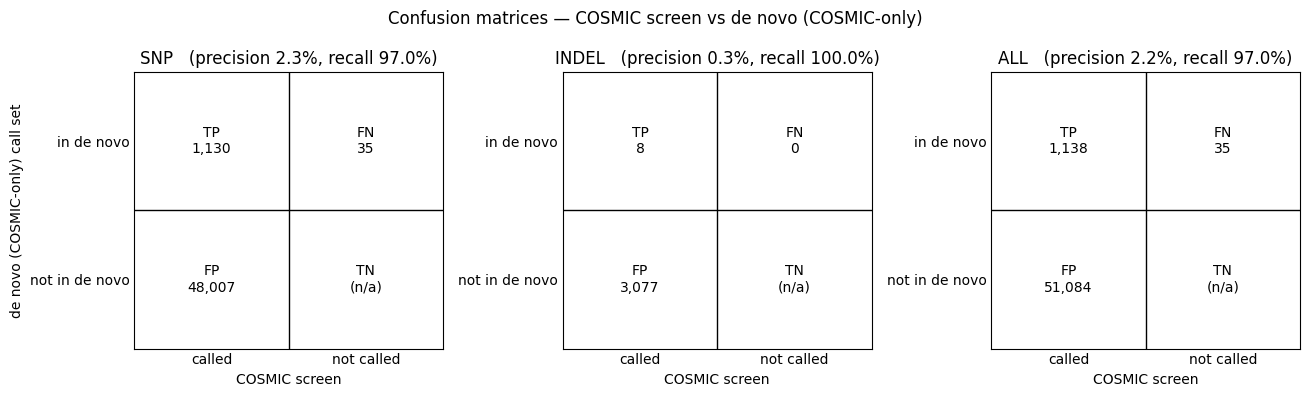


Reading these matrices:
  Recall is the meaningful axis: the de novo VCRS reference is a strict subset of the
  COSMIC one, so every de novo call SHOULD be recoverable by the screen. The residual
  FNs are the multimapping-dilution cases dissected in the next section.
  Precision is low BY CONSTRUCTION and is not an error rate: the screen interrogates
  ~1.36M COSMIC variants while de novo only proposed the small COSMIC-matching subset,
  so nearly everything the screen finds outside that subset is counted FP here.
time: 201 ms (started: 2026-07-18 11:20:27 -07:00)


In [ ]:
import matplotlib.pyplot as plt


def happy_confusion_counts(summary_csv):
    """{type: (TP, FP, FN)} straight from a hap.py summary CSV (PASS rows), plus an
    ALL row summing SNP + INDEL.  TP/FN are truth-side, FP is query-side."""
    summ = pd.read_csv(summary_csv)
    summ = summ[summ["Filter"] == "PASS"].set_index("Type")
    cms = {t: (int(summ.loc[t, "TRUTH.TP"]), int(summ.loc[t, "QUERY.FP"]), int(summ.loc[t, "TRUTH.FN"]))
           for t in ("SNP", "INDEL") if t in summ.index}
    cms["ALL"] = tuple(sum(v) for v in zip(*cms.values()))
    return cms


def plot_confusion_matrices(summary_csv, truth_label="de novo (COSMIC-only)",
                            query_label="COSMIC screen", verbose=True):
    """Plain, color-free SNP / INDEL / ALL confusion matrices.  Rows are the de novo call
    set (the truth track here), columns are the COSMIC screen (the query track).  The TN
    cell is n/a: the screen's negative space is the whole 1.36M-variant catalog."""
    cms = happy_confusion_counts(summary_csv)

    if verbose:
        print(f"{query_label} vs {truth_label} — confusion counts:")
        for name, (tp, fp, fn) in cms.items():
            prec = tp / (tp + fp) if tp + fp else float("nan")
            rec = tp / (tp + fn) if tp + fn else float("nan")
            print(f"  {name:5s}  TP={tp:>6,}   FP={fp:>6,}   FN={fn:>4,}   "
                  f"precision={prec:.1%}, recall={rec:.1%}")

    fig, axes = plt.subplots(1, len(cms), figsize=(4.4 * len(cms), 4))
    for ax, (name, (tp, fp, fn)) in zip(np.atleast_1d(axes), cms.items()):
        cells = [[f"TP\n{tp:,}", f"FN\n{fn:,}"],
                 [f"FP\n{fp:,}", "TN\n(n/a)"]]
        for i in range(2):
            for j in range(2):
                ax.text(j, i, cells[i][j], ha="center", va="center", fontsize=10, color="black")
        ax.set_xlim(-0.5, 1.5); ax.set_ylim(1.5, -0.5)   # row 0 at top
        ax.axhline(0.5, color="black", lw=1); ax.axvline(0.5, color="black", lw=1)
        ax.set_xticks([0, 1]); ax.set_xticklabels(["called", "not called"])
        ax.set_yticks([0, 1]); ax.set_yticklabels(["in de novo", "not in de novo"])
        ax.tick_params(length=0)
        for sp in ax.spines.values():
            sp.set_visible(True); sp.set_color("black")
        prec = tp / (tp + fp) if tp + fp else float("nan")
        rec = tp / (tp + fn) if tp + fn else float("nan")
        ax.set_title(f"{name}   (precision {prec:.1%}, recall {rec:.1%})")
        ax.set_xlabel(query_label)
    np.atleast_1d(axes)[0].set_ylabel(f"{truth_label} call set")
    fig.suptitle(f"Confusion matrices — {query_label} vs {truth_label}")
    plt.tight_layout(); plt.show()
    return cms


cosmic_cms = plot_confusion_matrices(os.path.join(happy_out, f"varseek_vs_{label}.summary.csv"))

print("\nReading these matrices:")
print("  Recall is the meaningful axis: the de novo VCRS reference is a strict subset of the\n"
      "  COSMIC one, so every de novo call SHOULD be recoverable by the screen. The residual\n"
      "  FNs are the multimapping-dilution cases dissected in the next section.")
print("  Precision is low BY CONSTRUCTION and is not an error rate: the screen interrogates\n"
      "  ~1.36M COSMIC variants while de novo only proposed the small COSMIC-matching subset,\n"
      "  so nearly everything the screen finds outside that subset is counted FP here.")

## Why the COSMIC screen "misses" a handful of de novo calls

hap.py reports a few false negatives: variants the de novo run detects but the COSMIC
screen does not. They are **not** missing from the COSMIC index, and the reads are **not**
lost. Two effects compound:

1. **Multimapping dilution.** COSMIC contains many variants within a k-mer window of each
   other. `kb count --mm` splits each read evenly across every VCRS in its equivalence
   class, so a read worth `1` in the small de novo index is worth `1/N` in the 1.36M-VCRS
   COSMIC index.
2. **A per-entry threshold.** `vk clean` applies `min_counts` element-wise per
   (cell x VCRS) entry, so every fraction below 1 is set to 0 — regardless of how many
   reads support the variant in total.

The cell below demonstrates this by comparing the **raw** `kb count` matrices (before
`vk clean`) from the two runs.

In [ ]:
import re
from fractions import Fraction

import anndata as ad
import numpy as np
import pandas as pd

# The RAW kb count matrices, before vk clean touches them.
raw_denovo = ad.read_h5ad(f"{vk_count_out_dir_denovo}/kb_count_out_vcrs/counts_unfiltered/adata.h5ad")
raw_cosmic = ad.read_h5ad(f"{vk_count_out_dir_cosmic}/kb_count_out_vcrs/counts_unfiltered/adata.h5ad")


def variant_totals(adata):
    """Column sums keyed by individual variant (a VCRS header may merge several with ';')."""
    totals = np.asarray(adata.X.sum(axis=0)).ravel()
    out = {}
    for j, header in enumerate(adata.var_names):
        # set(): some headers repeat the same variant (e.g. "1:g.13778644T>A;1:g.13778644T>A"),
        # which would otherwise double-count that column's reads.
        for v in set(str(header).split(";")):
            if v:
                out[v] = out.get(v, 0.0) + totals[j]
    return out


def variant_columns(adata, variant):
    """Every dense column whose header carries `variant` (a variant can appear in more
    than one merged VCRS header, so taking only the first would under-count it)."""
    return [
        np.asarray(adata.X[:, j].todense()).ravel()
        for j, header in enumerate(adata.var_names)
        if variant in str(header).split(";")
    ]


def cell_entries(adata, variant):
    """All non-zero per-cell values across the columns carrying `variant`."""
    cols = variant_columns(adata, variant)
    if not cols:
        return np.array([])
    stacked = np.concatenate(cols)
    return stacked[stacked > 0]


def as_fracs(values, limit=100000, max_shown=5):
    """Distinct per-cell values rendered as exact fractions, truncated for readability.
    The denominator is the size of the equivalence class the read was split across."""
    uniq = sorted({Fraction(float(v)).limit_denominator(limit) for v in values})
    shown = ", ".join(str(f) for f in uniq[:max_shown])
    return shown + (f", ... (+{len(uniq) - max_shown})" if len(uniq) > max_shown else "")


# Show the worst offenders rather than all of them; the tables get unreadable otherwise.
MAX_ROWS = 12


# The variants the de novo run detects but the COSMIC screen does not -- i.e. hap.py's FNs.
det_denovo = {v for v, c in variant_totals(ad.read_h5ad(adata_cleaned_denovo)).items() if c >= 1}
det_cosmic = {v for v, c in variant_totals(ad.read_h5ad(adata_cleaned_cosmic)).items() if c >= 1}
missed = sorted(det_denovo - det_cosmic)

tot_denovo, tot_cosmic = variant_totals(raw_denovo), variant_totals(raw_cosmic)
# worst-first: the variants with the most de novo support are the most striking losses
missed = sorted(missed, key=lambda v: -tot_denovo.get(v, 0.0))

print(f"{len(missed)} de novo call(s) are not detected by the COSMIC screen"
      f"{' - showing the ' + str(MAX_ROWS) + ' with the most de novo support' if len(missed) > MAX_ROWS else ''}.\n")
print("=" * 80)
print("1. Per-cell entries: whole reads in the de novo index, 1/N fractions in COSMIC")
print("=" * 80)
rows = []
for v in missed[:MAX_ROWS]:
    d_ent, c_ent = cell_entries(raw_denovo, v), cell_entries(raw_cosmic, v)
    rows.append({
        "variant": v,
        "de novo raw": round(tot_denovo.get(v, 0.0), 3),
        "COSMIC raw": round(tot_cosmic.get(v, 0.0), 3),
        "de novo entries": as_fracs(d_ent),
        "COSMIC entries": as_fracs(c_ent),
        "all COSMIC entries < 1": bool((c_ent < 1).all()) if len(c_ent) else None,
    })
display(pd.DataFrame(rows))
print("Every COSMIC per-cell entry is a fraction k/N with N > 1 (k reads in that cell, each\n"
      "split N ways). That is only possible under --mm: bustools splits one read evenly\n"
      "across the N VCRSs in its equivalence class, contributing 1/N to each. In the de novo\n"
      "index the same reads land on whole integers, because the competing COSMIC VCRSs that\n"
      "create the ambiguity are simply not in that index.\n"
      "Note this holds per CELL even where the column TOTAL happens to come out integral.\n")

print("=" * 80)
print("2. How much signal each variant loses in the COSMIC index")
print("=" * 80)
rows = []
for v in missed[:MAX_ROWS]:
    d, c = tot_denovo.get(v, 0.0), tot_cosmic.get(v, 0.0)
    ent = cell_entries(raw_cosmic, v)
    rows.append({
        "variant": v,
        "de novo raw": round(d, 2),
        "COSMIC raw": round(c, 2),
        "signal retained": f"{c / d:.1%}" if d else "n/a",
        "cells with signal": len(ent),
        "largest entry": f"{ent.max():.4f}" if len(ent) else "n/a",
    })
display(pd.DataFrame(rows))
print("The same reads survive into the COSMIC run, but each contributes only a fraction of a\n"
      "count, so the variant retains a few percent of its de novo signal -- and, critically,\n"
      "no single cell ever reaches a whole count.\n")
print("NOTE: the exact equivalence-class size cannot be read off these per-cell values. A cell\n"
      "holding several reads split different ways sums to a value that is not a clean 1/N, so\n"
      "recovering N would require the BUS records (kb_count_out_vcrs/output.bus + matrix.ec).\n")

print("Positional neighbours are a lower bound on the competition. At w=37/k=41 a VCRS spans\n"
      "~75bp, so COSMIC variants within +/-40bp necessarily share k-mers -- but k-mer sharing\n"
      "across the 1.36M-variant catalog (paralogues, repeats, recurrent motifs) reaches much\n"
      "further, which is why some variants lose far more signal than their local cluster explains:\n")
for v in missed[:3]:
    m = re.match(r"^(.+):g\.(\d+)", v)
    if not m:
        continue
    chrom, pos = m.group(1), int(m.group(2))
    cluster = [
        (var, c) for var, c in tot_cosmic.items()
        if (mm_ := re.match(r"^(.+):g\.(\d+)", var))
        and mm_.group(1) == chrom and abs(int(mm_.group(2)) - pos) <= 40 and c > 0
    ]
    cluster.sort(key=lambda r: -r[1])
    print(f"\n  {v}:  de novo raw = {tot_denovo.get(v, 0):.2f}, "
          f"{len(cluster)} COSMIC VCRS(s) within +/-40bp carrying reads")
    for var, c in cluster:
        mark = "   <-- the 'missed' variant" if var == v else ""
        print(f"       {var:34s} COSMIC raw = {c:9.3f}{mark}")
    print(f"       {'local cluster total':34s}              {sum(c for _, c in cluster):9.3f}")
print("\nWhere the local cluster total falls far short of the de novo count, the reads went to\n"
      "VCRSs outside the +/-40bp window entirely.\n")

print("=" * 80)
print("3. vk clean then zeroes the fractions -- min_counts is a PER-CELL-ENTRY threshold")
print("=" * 80)
print("varseek_clean.py:  adata.X = adata.X.multiply(adata.X >= min_counts)"
      f"    [min_counts={min_counts_clean}]\n\n"
      "The threshold is applied element-wise, per (cell x VCRS) entry -- not to the column\n"
      "total. Since every entry above is a fraction < 1, ALL of them are zeroed, no matter\n"
      "how many reads support the variant overall.\n")
actual_cleaned = variant_totals(ad.read_h5ad(adata_cleaned_cosmic))
rows = []
for v in missed[:MAX_ROWS]:
    ent = cell_entries(raw_cosmic, v)
    if not len(ent):
        continue
    # Apply the threshold exactly as vk clean does: element-wise, within each column,
    # then sum the survivors across every column carrying this variant.
    predicted = sum(col[col >= min_counts_clean].sum() for col in variant_columns(raw_cosmic, v))
    rows.append({
        "variant": v,
        "cells with signal": len(ent),
        "raw total": round(ent.sum(), 3),
        "largest entry": str(Fraction(float(ent.max())).limit_denominator(64)),
        f"entries >= {min_counts_clean}": int((ent >= min_counts_clean).sum()),
        "predicted cleaned": round(predicted, 3),
        "actual cleaned": round(actual_cleaned.get(v, 0.0), 3),
    })
display(pd.DataFrame(rows))
print("'predicted cleaned' reproduces vk clean's actual output exactly, confirming the\n"
      "mechanism: these variants ARE seen by the COSMIC screen, but multimapping dilution\n"
      "plus a per-entry threshold drives them to zero, so hap.py scores them as FNs.")

# Control: the same threshold applied to a variant the screen DOES detect.
kept = sorted(det_denovo & det_cosmic)
if kept:
    ctrl = next((v for v in kept if len(cell_entries(raw_cosmic, v))), None)
    if ctrl:
        ent = cell_entries(raw_cosmic, ctrl)
        print(f"\nControl -- {ctrl} (detected by both): entries "
              f"{as_fracs(ent)}; "
              f"{int((ent >= min_counts_clean).sum())} of {len(ent)} clear the threshold.")

35 de novo call(s) are not detected by the COSMIC screen - showing the 12 with the most de novo support.

1. Per-cell entries: whole reads in the de novo index, 1/N fractions in COSMIC


,variant,de novo raw,COSMIC raw,de novo entries,COSMIC entries,all COSMIC entries < 1
0,16:g.10055093G>A,5342.50,90.325,"1/2, 1, 3/2, 2, 5/2, ... (+25)","1/199, 1/166, 1/157, 1/156, 1/152, ... (+835)",True
1,17:g.20147164T>C,2429.75,81.786,"1/4, 1/3, 1/2, 7/12, 1, ... (+37)","1/116, 1/108, 1/107, 1/106, 1/104, ... (+622)",True
2,12:g.112424891A>G,1153.00,14.647,"1/4, 1/3, 7/12, 2/3, 5/6, ... (+25)","1/333, 1/332, 1/321, 1/310, 1/309, ... (+776)",True
3,6:g.36680346C>G,1103.50,13.896,"1/4, 1/3, 7/12, 2/3, 5/6, ... (+21)","1/333, 1/332, 1/321, 1/310, 1/309, ... (+761)",True
4,1:g.204557932C>T,109.00,29.333,"1, 2","1/4, 1/3, 1/2, 3/4",True
5,6:g.156856704A>T,35.50,0.616,"1/4, 1/2, 1, 5/4","1/306, 1/293, 1/284, 1/279, 1/278, ... (+18)",True
6,1:g.198642903T>C,19.50,0.257,"1/2, 1","1/62, 1/56, 1/43, 1/42, 1/39, ... (+1)",True
7,7:g.6390468C>T,11.50,2.994,"1/2, 1","1/62, 1/33, 1/28, 1/3, 1/2",True
8,21:g.35040771C>A,7.00,3.500,1,1/2,True
9,9:g.77821726T>G,6.00,0.827,1,"1/26, 1/4",True


Every COSMIC per-cell entry is a fraction k/N with N > 1 (k reads in that cell, each
split N ways). That is only possible under --mm: bustools splits one read evenly
across the N VCRSs in its equivalence class, contributing 1/N to each. In the de novo
index the same reads land on whole integers, because the competing COSMIC VCRSs that
create the ambiguity are simply not in that index.
Note this holds per CELL even where the column TOTAL happens to come out integral.

2. How much signal each variant loses in the COSMIC index


,variant,de novo raw,COSMIC raw,signal retained,cells with signal,largest entry
0,16:g.10055093G>A,5342.50,90.32,1.7%,2790,0.6583
1,17:g.20147164T>C,2429.75,81.79,3.4%,973,0.6113
2,12:g.112424891A>G,1153.00,14.65,1.3%,1135,0.5116
3,6:g.36680346C>G,1103.50,13.90,1.3%,1130,0.5259
4,1:g.204557932C>T,109.00,29.33,26.9%,95,0.7500
5,6:g.156856704A>T,35.50,0.62,1.7%,61,0.0526
6,1:g.198642903T>C,19.50,0.26,1.3%,11,0.0263
7,7:g.6390468C>T,11.50,2.99,26.0%,13,0.5000
8,21:g.35040771C>A,7.00,3.50,50.0%,7,0.5000
9,9:g.77821726T>G,6.00,0.83,13.8%,5,0.2500


The same reads survive into the COSMIC run, but each contributes only a fraction of a
count, so the variant retains a few percent of its de novo signal -- and, critically,
no single cell ever reaches a whole count.

NOTE: the exact equivalence-class size cannot be read off these per-cell values. A cell
holding several reads split different ways sums to a value that is not a clean 1/N, so
recovering N would require the BUS records (kb_count_out_vcrs/output.bus + matrix.ec).

Positional neighbours are a lower bound on the competition. At w=37/k=41 a VCRS spans
~75bp, so COSMIC variants within +/-40bp necessarily share k-mers -- but k-mer sharing
across the 1.36M-variant catalog (paralogues, repeats, recurrent motifs) reaches much
further, which is why some variants lose far more signal than their local cluster explains:


  16:g.10055093G>A:  de novo raw = 5342.50, 2 COSMIC VCRS(s) within +/-40bp carrying reads
       16:g.10055093G>A                   COSMIC raw =    90.325   <-- the 'm

,variant,cells with signal,raw total,largest entry,entries >= 1,predicted cleaned,actual cleaned
0,16:g.10055093G>A,2790,90.325,27/41,0,0.0,0.0
1,17:g.20147164T>C,973,81.786,11/18,0,0.0,0.0
2,12:g.112424891A>G,1135,14.647,22/43,0,0.0,0.0
3,6:g.36680346C>G,1130,13.896,10/19,0,0.0,0.0
4,1:g.204557932C>T,95,29.333,3/4,0,0.0,0.0
5,6:g.156856704A>T,61,0.616,1/19,0,0.0,0.0
6,1:g.198642903T>C,11,0.257,1/38,0,0.0,0.0
7,7:g.6390468C>T,13,2.994,1/2,0,0.0,0.0
8,21:g.35040771C>A,7,3.500,1/2,0,0.0,0.0
9,9:g.77821726T>G,5,0.827,1/4,0,0.0,0.0


'predicted cleaned' reproduces vk clean's actual output exactly, confirming the
mechanism: these variants ARE seen by the COSMIC screen, but multimapping dilution
plus a per-entry threshold drives them to zero, so hap.py scores them as FNs.

Control -- 10:g.102630546A>G (detected by both): entries 1; 4 of 4 clear the threshold.
time: 38.3 s (started: 2026-07-18 11:20:27 -07:00)
